### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from scipy import stats
import shap
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

/opt/anaconda3/envs/sklearn-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load the Data and Preprocessing

In [ ]:
# Load the uploaded label file
df = pd.read_csv("hscssp3_dr17_gc1_class_rs20231229.csv")

# Show structure of labels
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 687859 entries, 0 to 687858
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              687859 non-null  int64  
 1   id_sdss         687859 non-null  int64  
 2   ra              687859 non-null  float64
 3   dec             687859 non-null  float64
 4   skymap_id       687859 non-null  int64  
 5   sample          687859 non-null  str    
 6   z               687859 non-null  float64
 7   z_flag          687859 non-null  str    
 8   prob_sp         687859 non-null  float64
 9   prob_rg         687859 non-null  float64
 10  reduced_chisq   687859 non-null  float64
 11  mstar           687859 non-null  float64
 12  mstar_err68min  687859 non-null  float64
 13  mstar_err68max  687859 non-null  float64
 14  sfr             687859 non-null  float64
 15  sfr_err68min    687859 non-null  float64
 16  sfr_err68max    687859 non-null  float64
dtypes: float64(12), int64

In [ ]:
# make class from  'prob_sp'
def make_target(p):
    if p > 0.79:
        return "Spiral"
    elif p < 0.5:
        return "Non-Spiral"
    else:
        return "Intermediate"

df["target_class"] = df["prob_sp"].apply(make_target)

print("\nDistribusi target_class:")
print(df["target_class"].value_counts())

# Drop only identity

drop_cols = ["id", "id_sdss", "skymap_id", "ra", "dec"]
df_proportion = df["target_class"]
df_proportion.to_csv("data_gc_proportion.csv", index=False)
df = df.drop(columns=drop_cols)

print("\nKolom setelah drop ID:")
print(df.columns)

# One-hot encoding only for categorical columns

categorical_cols = ["sample", "z_flag"]

df = pd.get_dummies(df, columns=categorical_cols)

# Convert bool → int (0/1)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("\nKolom setelah OneHotEncoding:")
print(df.columns)
# Label encoding target

le = LabelEncoder()
df["target_class"] = le.fit_transform(df["target_class"])

print("\nMapping target_class:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} → {i}")

# prob_sp used as a target, so it must be dropped
X = df.drop(columns=["target_class", "prob_sp"])
y = df["target_class"]
# Normalization

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Combine back with target
df_final = X_scaled.copy()
df_final["target_class"] = y.values

Dataset shape awal: (687859, 17)
                  id              id_sdss         ra       dec  skymap_id  \
0  36411435655366853  1237679438812610985  30.604164 -7.084937   82790002   
1  36411435655379508  1237679438812610641  30.578960 -7.080802   82790002   
2  36411435655380369  1237679438812610794  30.609513 -7.044947   82790002   
3  36411439950347843  1237679340030001416  30.611033 -6.962489   82790003   
4  36411439950348757  1237679340030001508  30.609168 -6.929949   82790003   

  sample         z z_flag   prob_sp   prob_rg  reduced_chisq         mstar  \
0    sub  0.203322   phot  0.770146  0.025958         2.7125  2.338000e+10   
1    sub  0.106500   phot  0.806715  0.024644         4.0000  1.442400e+10   
2    sub  0.181253   phot  0.903872  0.019853         2.4300  1.007800e+10   
3    sub  0.187636   phot  0.063089  0.096538        22.3725  9.370500e+10   
4    sub  0.076742   phot  0.299430  0.015849         0.0800  5.051100e+08   

   mstar_err68min  mstar_err68max  

In [ ]:
# Preparation data using df_final
# Split features and target from df_final
X = df_final.drop('target_class', axis=1)
y = df_final['target_class']

print("=" * 60)
print("Data before Resampling")
print("=" * 60)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nClass distribution before Resampling:")
print(y.value_counts().sort_index())
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    print(f"  Class {cls}: {count} samples ({count/len(y)*100:.2f}%)")

# Calculate class weights from original distribution
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))

print("\n" + "=" * 60)
print("Class Weights")
print("=" * 60)
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

# Resampling with undersampling or oversampling, choose one 

# Undersampling
nearmiss = NearMiss(
   version=1,  
    n_neighbors=3
)
# Oversampling
# smote_tomek = SMOTETomek()

# X_resampled, y_resampled = smote_tomek.fit_resample(X, y)
X_resampled, y_resampled = nearmiss.fit_resample(X, y)

print("\n" + "=" * 60)
print("Data after Resampling")
print("=" * 60)
print(f"Shape X_resampled: {X_resampled.shape}")
print(f"Shape y_resampled: {y_resampled.shape}")
print("\nClass distribution after Resampling:")
unique, counts = np.unique(y_resampled, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"  Class {cls}: {count} samples ({count/len(y_resampled)*100:.2f}%)")

# Convert to DataFrame for easier LDA later
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled_series = pd.Series(y_resampled, name='target_class')

NameError: name 'df_final' is not defined

### Feature Analysis

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=209,
    class_weight="balanced"
)
# Split 7-1-2
X_temp, X_test, y_temp, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=209, stratify=y_resampled
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=209, stratify=y_temp
)

rf.fit(X_train, y_train)
importance = rf.feature_importances_

In [18]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print("Top RF Feature Importance")
print(rf_importance.head(10))

Top RF Feature Importance
prob_rg           0.182221
mstar_err68min    0.126519
mstar             0.119477
mstar_err68max    0.105429
sfr_err68max      0.099347
sfr               0.095975
z                 0.094975
sfr_err68min      0.086886
reduced_chisq     0.077236
z_flag_phot       0.005472
dtype: float64


In [27]:
# Train model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=209,
    class_weight="balanced"
)

rf.fit(X_resampled, y_resampled)

KeyboardInterrupt: 

Top RF Feature Importance
prob_rg           0.182221
mstar_err68min    0.126519
mstar             0.119477
mstar_err68max    0.105429
sfr_err68max      0.099347
sfr               0.095975
z                 0.094975
sfr_err68min      0.086886
reduced_chisq     0.077236
z_flag_phot       0.005472
z_flag_spec       0.005470
sample_main       0.000525
sample_sub        0.000469
dtype: float64


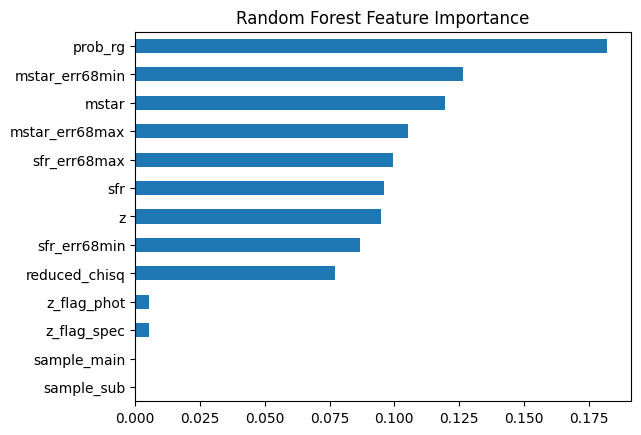

In [19]:
rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_test.columns
).sort_values(ascending=False)

print("Top RF Feature Importance")
print(rf_importance.head(15))
# Plot
rf_importance.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

In [20]:
result = permutation_importance(rf, X_test, y_test)
importance = result.importances_mean
perm_importance = pd.Series(
    importance,
    index=X_test.columns
).sort_values(ascending=False)

print("\nTop Permutation Importance")
print(perm_importance.head(10))


Top Permutation Importance
prob_rg           0.115287
z                 0.077119
mstar_err68min    0.077119
sfr_err68max      0.035179
mstar             0.034113
sfr               0.031559
sfr_err68min      0.024862
mstar_err68max    0.014551
z_flag_phot       0.007924
z_flag_spec       0.007473
dtype: float64


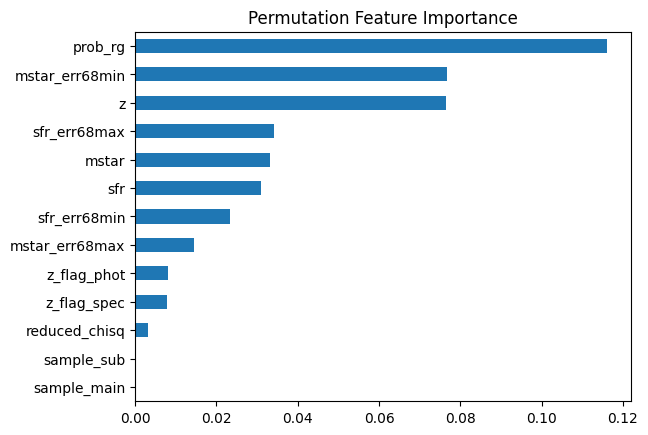

In [16]:
perm_importance.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.show()

In [22]:
importance_df = pd.DataFrame({
    "RF_Importance": rf_importance,
    "Permutation_Importance": perm_importance
})

importance_df = importance_df.sort_values(
    by="Permutation_Importance",
    ascending=False
)

print(importance_df.head(20))

                RF_Importance  Permutation_Importance
prob_rg              0.182221                0.115287
mstar_err68min       0.126519                0.077119
z                    0.094975                0.077119
sfr_err68max         0.099347                0.035179
mstar                0.119477                0.034113
sfr                  0.095975                0.031559
sfr_err68min         0.086886                0.024862
mstar_err68max       0.105429                0.014551
z_flag_phot          0.005472                0.007924
z_flag_spec          0.005470                0.007473
reduced_chisq        0.077236                0.004269
sample_main          0.000525               -0.000006
sample_sub           0.000469               -0.000017


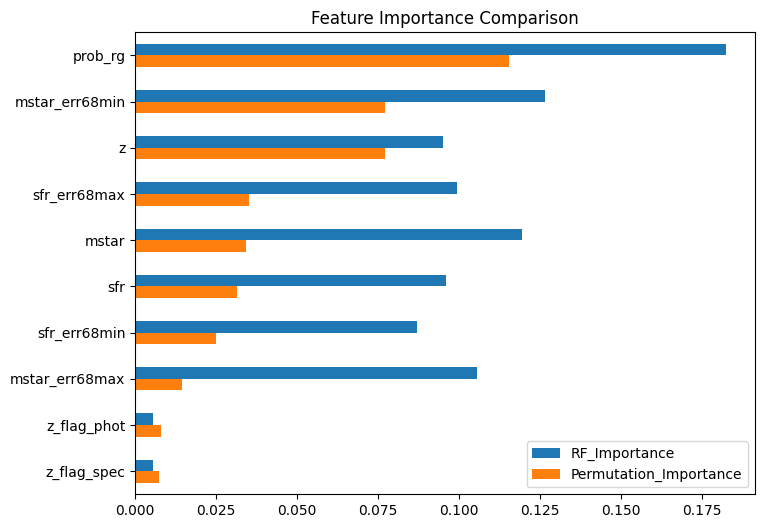

In [23]:
importance_df.head(10).plot(kind="barh", figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("Feature Importance Comparison")
plt.show()

In [6]:
explainer = shap.TreeExplainer(rf)
X_sample = X_test.sample(300, random_state=209)

shap_values = explainer.shap_values(X_sample)

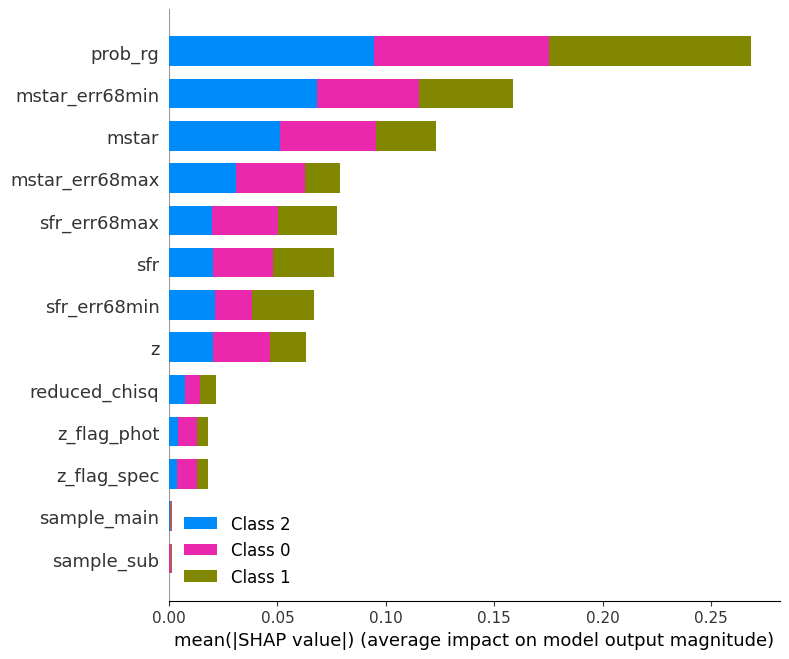

In [9]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [13]:
feature_names = X_sample.columns
class_names = ['Intermediate','Non-Spiral','Spiral']

shap_importance = {}

for i, class_name in enumerate(class_names):

    vals = np.abs(shap_values[:,:,i]).mean(axis=0)

    shap_importance[class_name] = vals

df_shap = pd.DataFrame(shap_importance, index=feature_names)

print(df_shap)

                Intermediate  Non-Spiral    Spiral
z                   0.026356    0.016611  0.020387
prob_rg             0.080957    0.093140  0.094295
reduced_chisq       0.007133    0.007597  0.007116
mstar               0.044614    0.027640  0.050934
mstar_err68min      0.047226    0.043336  0.068094
mstar_err68max      0.031747    0.016280  0.030967
sfr                 0.027689    0.028164  0.020141
sfr_err68min        0.017020    0.028599  0.021154
sfr_err68max        0.030423    0.027477  0.019642
sample_main         0.000681    0.000447  0.000233
sample_sub          0.000604    0.000432  0.000173
z_flag_phot         0.009084    0.005157  0.003927
z_flag_spec         0.009003    0.005168  0.003835
